# Taller Guiado de Visualización de datos

# 0. Cargar los datos

In [ ]:
## Instalar librerias de graficación
!pip install matplotlib seaborn

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ruta = "D:\\BIT\\Data Science\\Data Science BootCamp 202605\\Clase 10 - Visualizacion de datos\\notas_estudiantes.csv"

notas = pd.read_csv(ruta, encoding="latin-1")
notas

,Unnamed: 0,id_estudiante,edad,materia,horas_estudio_semana,asistencia_pct,nota_final
0,120,121,99,Matemáticas,7.710223,80.544975,-20.000000
1,97,98,16,Historia,15.728250,79.839553,26.556169
2,57,58,15,Literatura,10.105791,86.220098,27.271861
3,156,157,18,Historia,10.869325,87.029230,32.508914
4,147,148,14,Literatura,9.532968,79.445229,37.699148
...,...,...,...,...,...,...,...
295,112,113,16,Literatura,11.502752,87.670503,106.051234
296,161,162,17,Matemáticas,8.775774,81.122984,106.596286
297,287,288,16,Literatura,13.477989,35.000000,107.394993
298,229,230,17,Ciencias,8.719357,63.011940,108.695640


# 1. Explorar los datos y analizar distribución de las variables numericas

- Cantidad de filas y columnas
- Tipos de datos
- Cantidad de Valores nulos
- Promedios, min, max de cada columna númerica
- Cúal gráfica sirve para ver la distribución de una variable númerica?

In [ ]:
print(notas.shape)

notas.info()

(300, 7)
<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            300 non-null    int64  
 1   id_estudiante         300 non-null    int64  
 2   edad                  300 non-null    int64  
 3   materia               300 non-null    str    
 4   horas_estudio_semana  300 non-null    float64
 5   asistencia_pct        300 non-null    float64
 6   nota_final            300 non-null    float64
dtypes: float64(3), int64(3), str(1)
memory usage: 19.4 KB


In [7]:
notas.describe()

,Unnamed: 0,id_estudiante,edad,horas_estudio_semana,asistencia_pct,nota_final
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,149.500000,150.500000,17.336667,9.813111,84.759789,71.472652
std,86.746758,86.746758,13.450640,3.098198,11.790443,17.359817
min,0.000000,1.000000,5.000000,0.500000,20.000000,-20.000000
25%,74.750000,75.750000,14.000000,7.675612,79.342545,60.566313
50%,149.500000,150.500000,16.000000,9.767200,86.181187,71.571825
75%,224.250000,225.250000,16.000000,11.902704,91.764898,81.431817
max,299.000000,300.000000,120.000000,19.236642,100.000000,180.000000


In [9]:
print(f"promedio de notas:\n{notas['nota_final'].mean():.2f}")

promedio de notas:
71.47


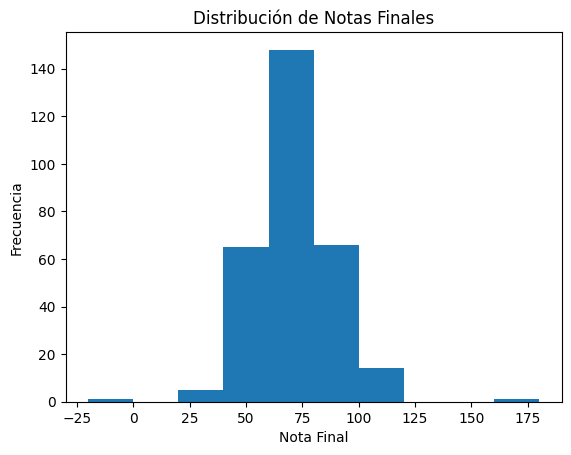

In [10]:
## Histogramas

plt.hist(notas['nota_final'])
plt.xlabel('Nota Final')
plt.ylabel('Frecuencia')
plt.title('Distribución de Notas Finales')
plt.show()

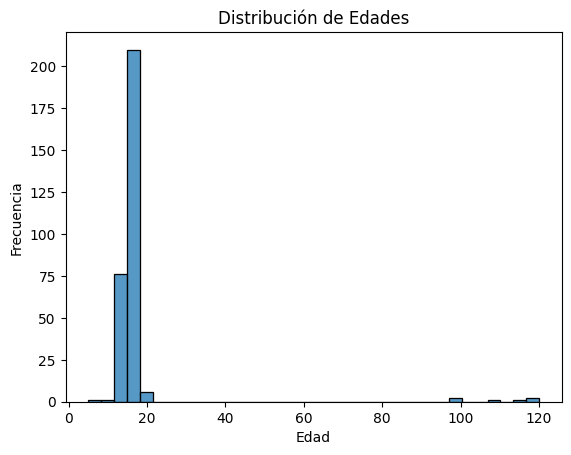

In [18]:
sns.histplot(notas['edad'])
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.title('Distribución de Edades')
plt.show()

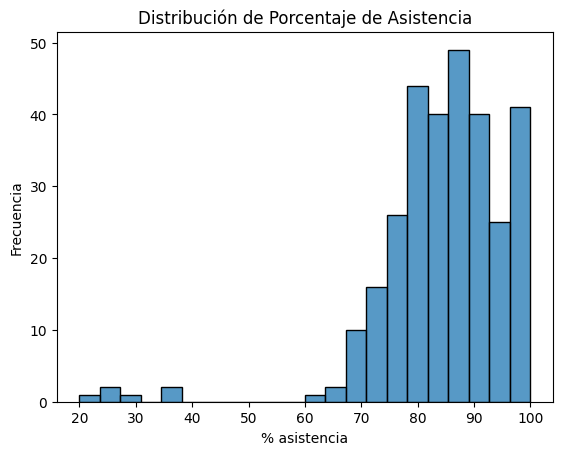

In [19]:
sns.histplot(notas['asistencia_pct'])
plt.xlabel('% asistencia')
plt.ylabel('Frecuencia')
plt.title('Distribución de Porcentaje de Asistencia')
plt.show()

# 2. Revisión de categorias
Hay una gráfica que me sirva para comparar valores segmentados por categorias?

In [28]:
promedio_materias = notas.groupby("materia")["nota_final"].mean()
promedio_materias

materia
Ciencias       69.708492
Historia       71.108663
Literatura     72.255597
Matemáticas    72.377808
Name: nota_final, dtype: float64

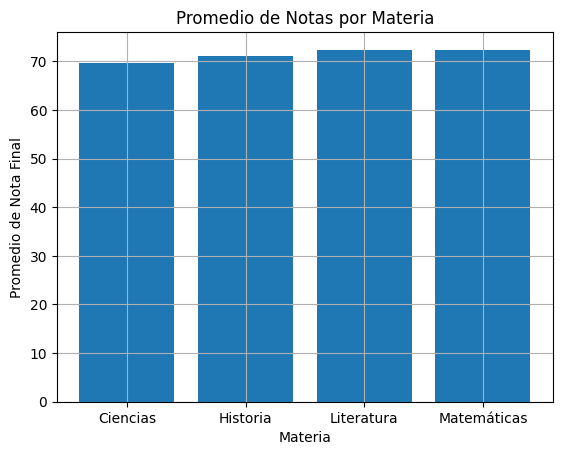

In [30]:
plt.bar(promedio_materias.index, promedio_materias.values)
plt.title('Promedio de Notas por Materia')
plt.xlabel('Materia')
plt.ylabel('Promedio de Nota Final')
plt.grid()
plt.show()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_15440\1757860340.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=notas, x='materia', y='nota_final', ci=None, estimator='mean')


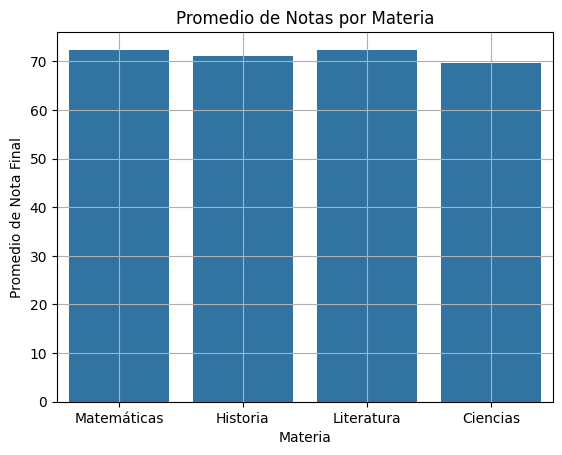

In [35]:
sns.barplot(data=notas, x='materia', y='nota_final', ci=None, estimator='mean')
plt.title('Promedio de Notas por Materia')
plt.xlabel('Materia')
plt.ylabel('Promedio de Nota Final')
plt.grid()
plt.show()

# 3. Detección de outliers / valores atípicos
Escoge una gráfica que me sirva para ver los outliers de manera clara y sencilla

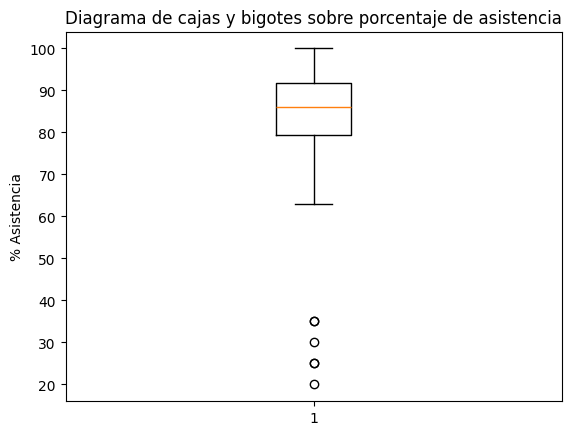

In [42]:
plt.boxplot(notas['asistencia_pct'])
plt.title('Diagrama de cajas y bigotes sobre porcentaje de asistencia')
plt.ylabel('% Asistencia')
plt.show()

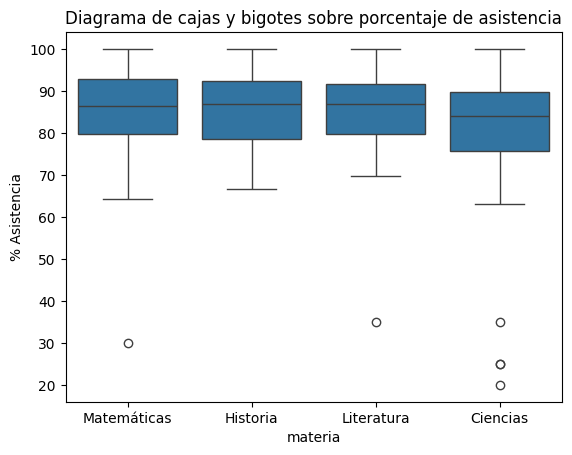

In [43]:
sns.boxplot(data=notas, y='asistencia_pct', x ='materia')
plt.title('Diagrama de cajas y bigotes sobre porcentaje de asistencia')
plt.ylabel('% Asistencia')
plt.show()

# 4. Análisis de relaciones lineales
(Qué gráficas me sirven para ver si dos variables númericas tienen relación?)

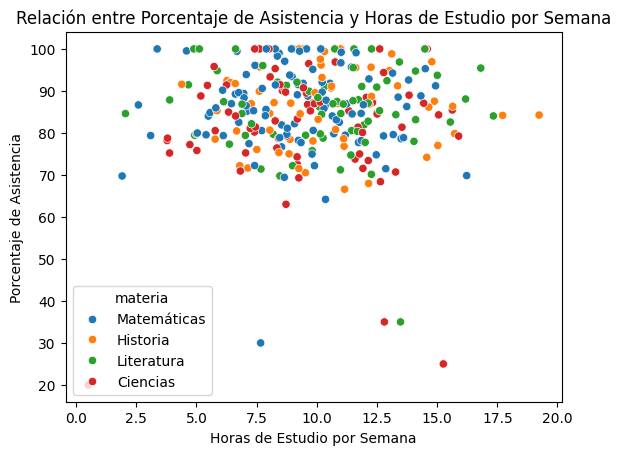

In [58]:
## Relación entre asistencia_pct y horas de estudio
sns.scatterplot(data=notas, x='horas_estudio_semana', y='asistencia_pct', hue='materia')
plt.title('Relación entre Porcentaje de Asistencia y Horas de Estudio por Semana')
plt.xlabel('Horas de Estudio por Semana')
plt.ylabel('Porcentaje de Asistencia')
plt.show()

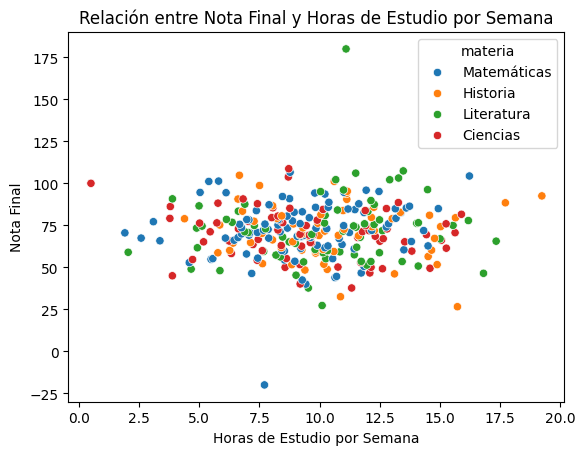

In [59]:
## Relación entre nota final y horas de estudio
sns.scatterplot(data=notas, x='horas_estudio_semana', y='nota_final', hue='materia')
plt.title('Relación entre Nota Final y Horas de Estudio por Semana')
plt.xlabel('Horas de Estudio por Semana')
plt.ylabel('Nota Final')
plt.show()

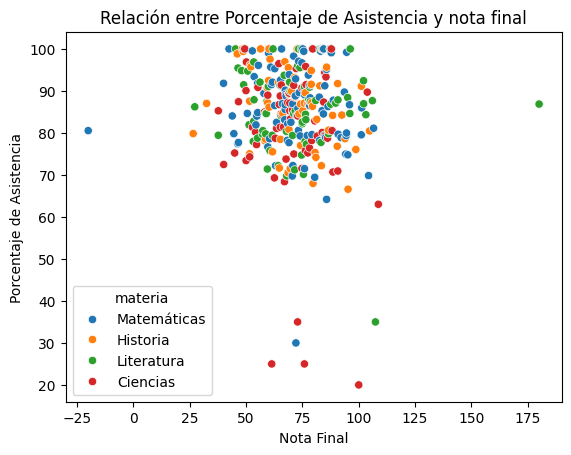

In [60]:
## Relación entre nota final y asistencia_pct
sns.scatterplot(data=notas, x='nota_final', y='asistencia_pct', hue='materia')
plt.title('Relación entre Porcentaje de Asistencia y nota final')
plt.xlabel('Nota Final')
plt.ylabel('Porcentaje de Asistencia')
plt.show()

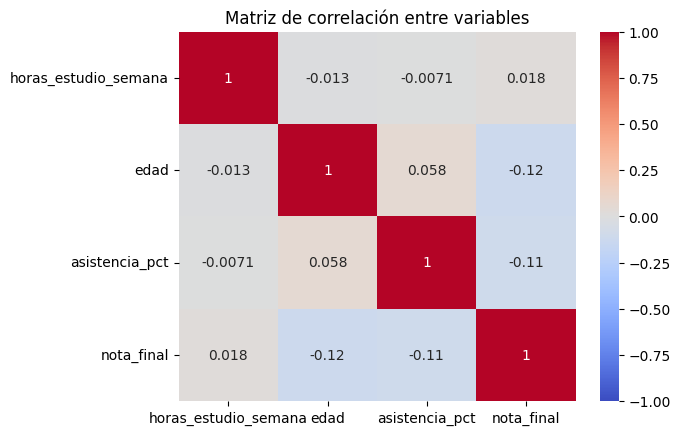

In [57]:
matrix = notas[['horas_estudio_semana','edad','asistencia_pct','nota_final']].corr()
sns.heatmap(matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de correlación entre variables')
plt.show()

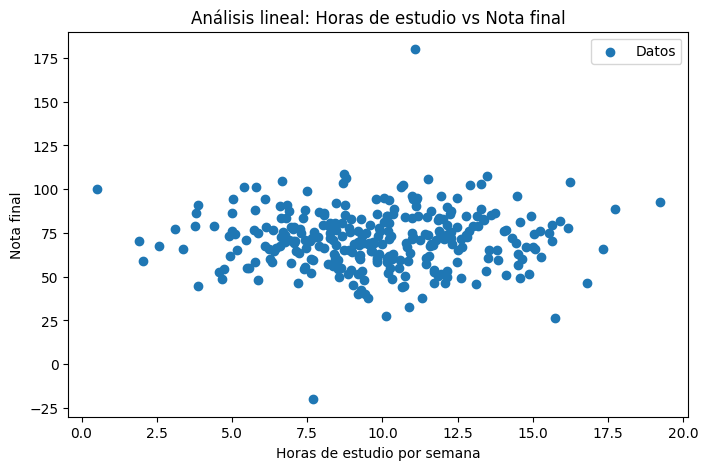

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(notas['horas_estudio_semana'], notas['nota_final'], label="Datos")
plt.plot(notas['horas_estudio_semana'], m*notas['horas_estudio_semana'] + b, color="red", label="Línea de tendencia")

plt.title("Análisis lineal: Horas de estudio vs Nota final")
plt.xlabel("Horas de estudio por semana")
plt.ylabel("Nota final")
plt.legend()

plt.show()

# Análizar la composición de una variable
(Cómo podemos evidenciar si una categoria predomina en el conjunto de datos?)

In [61]:
notas['materia'].value_counts()

materia
Matemáticas    98
Literatura     71
Ciencias       69
Historia       62
Name: count, dtype: int64

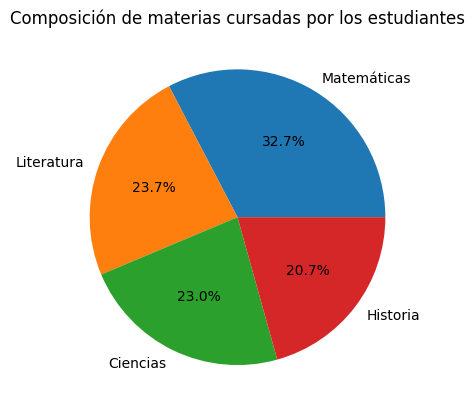

In [65]:
plt.pie(notas['materia'].value_counts(), labels=notas['materia'].value_counts().index, autopct='%1.1f%%')
plt.title("Composición de materias cursadas por los estudiantes")
plt.show()